In [1]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [2]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [3]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Reward: 0.08922658917237894
Reward: 0.07594202891664763
Reward: 0.22659663422543427
Reward: 0.20333618451382446
Reward: 0.25587539445315205


In [4]:
## test 4
env.sample_sentence(0,1)

'the athlete thinks the north path leads through the forest'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [5]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Reward: 0.14397507321310118
Skill: 0.173190108762735
Reward: 0.14167081872993229
Skill: 0.23754601911065154
Reward: 0.23172842491603388
Skill: 0.324978604077635
Reward: 0.21069813658722636
Skill: 0.402385066674463
Reward: 0.07116271099596642
Skill: 0.43665009757808293


### Forgetting Curve

[np.float64(0.99988645506544), np.float64(0.9998864136620615), np.float64(0.9998863372247632), np.float64(0.9998862303809294), np.float64(0.9998860966363995), np.float64(0.9998859387328088), np.float64(0.9998857588679175), np.float64(0.9998855588388382), np.float64(0.9998853401391596), np.float64(0.9998851040271215), np.float64(0.9998848515748661), np.float64(0.9998845837048982), np.float64(0.9998843012176455), np.float64(0.9998840048126731), np.float64(0.9998836951052755), np.float64(0.9998833726396361), np.float64(0.9998830378993959), np.float64(0.9998826913162372), np.float64(0.9998823332769246), np.float64(0.9998819641291349), np.float64(0.9998815841863237), np.float64(0.9998811937318184), np.float64(0.9998807930222857), np.float64(0.9998803822906869), np.float64(0.9998799617488121), np.float64(0.9998795315894656), np.float64(0.9998790919883593), np.float64(0.9998786431057612), np.float64(0.9998781850879376), np.float64(0.9998777180684187), np.float64(0.9998772421691153), np.float6

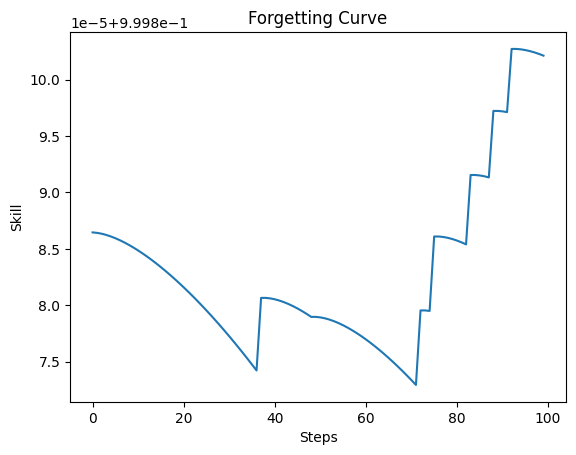

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [8]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from typing_env import TypingEnv

In [10]:
def run_random_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    K = env.K
    L = env.L
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = np.random.randint(0, K * L)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])  # final skill
        
    return all_rewards, all_skills

In [11]:
def select_action(env):
    
    scores = env.k - 0.1 * env.t
    weakest_bigram = np.argmin(scores)
    
    skill = env.k[weakest_bigram]
    
    if skill < 0.3:
        difficulty = 0
    elif skill < 0.5:
        difficulty = 1
    elif skill < 0.7:
        difficulty = 2
    elif skill < 0.85:
        difficulty = 3
    else:
        difficulty = 4
    
    return weakest_bigram * env.L + difficulty

In [12]:
def run_rule_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = select_action(env)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])
        
    return all_rewards, all_skills

In [13]:
random_rewards, random_skills = run_random_agent()
rule_rewards, rule_skills = run_rule_agent()

In [14]:
print("Random avg skill:", np.mean(random_skills))
print("Rule avg skill:", np.mean(rule_skills))

print("Random avg reward:", np.mean(random_rewards))
print("Rule avg reward:", np.mean(rule_rewards))

Random avg skill: 0.659512377706916
Rule avg skill: 0.4364268611657295
Random avg reward: 0.1341364514379422
Rule avg reward: 0.09727577963421999


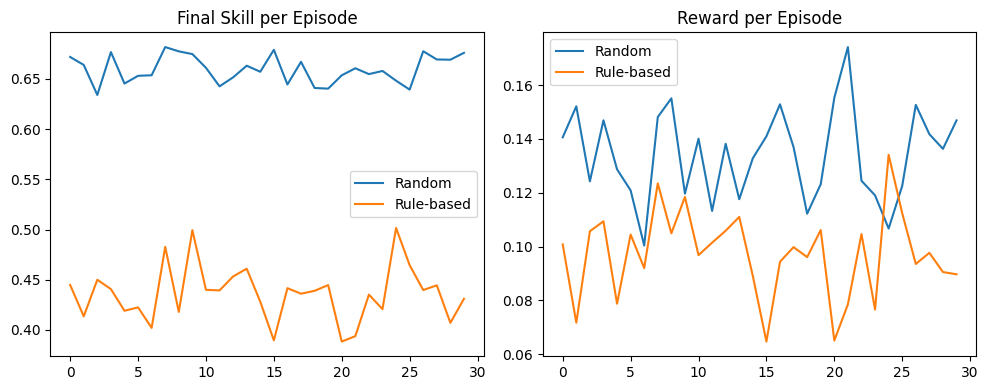

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(random_skills, label="Random")
plt.plot(rule_skills, label="Rule-based")
plt.title("Final Skill per Episode")
plt.legend()

plt.subplot(1,2,2)
plt.plot(random_rewards, label="Random")
plt.plot(rule_rewards, label="Rule-based")
plt.title("Reward per Episode")
plt.legend()

plt.tight_layout()
plt.show()

## test for q_learning agent

In [16]:
from q_learning import QLearningAgent

agent = QLearningAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Episode 10 | Reward: 0.1904 | Skill: 0.9236 | Epsilon: 0.990


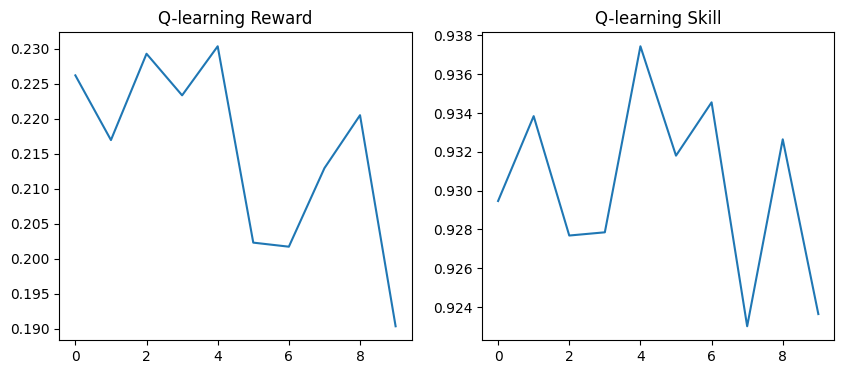

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(rewards)
plt.title("Q-learning Reward")

plt.subplot(1,2,2)
plt.plot(skills)
plt.title("Q-learning Skill")

plt.show()

## test for DQN agent

In [18]:
from dqn_agent import DQNAgent

agent = DQNAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Ep 1 | Reward: 0.2215 | Skill: 0.9268 | Eps: 0.995
Ep 2 | Reward: 0.2016 | Skill: 0.9185 | Eps: 0.990
Ep 3 | Reward: 0.2021 | Skill: 0.9280 | Eps: 0.985
Ep 4 | Reward: 0.1976 | Skill: 0.9175 | Eps: 0.980
Ep 5 | Reward: 0.2090 | Skill: 0.9174 | Eps: 0.975
Ep 6 | Reward: 0.2179 | Skill: 0.9244 | Eps: 0.970
Ep 7 | Reward: 0.2183 | Skill: 0.9260 | Eps: 0.966
Ep 8 | Reward: 0.2102 | Skill: 0.9333 | Eps: 0.961
Ep 9 | Reward: 0.1939 | Skill: 0.9309 | Eps: 0.956
Ep 10 | Reward: 0.2160 | Skill: 0.9333 | Eps: 0.951


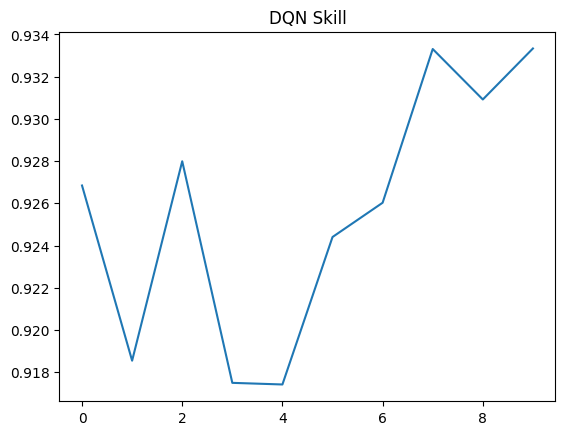

In [19]:
import matplotlib.pyplot as plt

plt.plot(skills)
plt.title("DQN Skill")
plt.show()